# Benchmark Analysis

     1 - 2D pyturbo binning performance will be evaluated on the dycoms data
     2 - Different subsets of the data will be evaluated (512*512,1024*1024,2048*2048,4096*4096)
     3 - For testing purposes, the bootstrap samples size will be fixed to 16*16
     4 - The number of bootstrap samples will vary between 60 and 1060 with a step of 500
     5 - We will vary the threshold eps = [0.001,0.003,0.008,0.022,0.060,0.17,0.46,1.3] - Note that the method might reach the maximum number of bootstrap samples without converging.
     6 - We will test both backends loky (multiprocessing) and threading.
     7 - The performance will be evaluated as the ratio between the execution time and the complexity Nlog(N)*Mlog(M) where N,M = dataset size.


# Benchmark Run

Starting bin_sf_2d Performance Benchmark

Testing backend: threading
----------------------------------------

Dataset size: 512×512
  Testing epsilon = 0.0010...Dimensions ('y', 'x') are already in the expected order
Using bootsize: {'x': 16, 'y': 16}
Bootstrappable dimensions: ['y', 'x']
Two bootstrappable dimensions. Available spacings: [1, 2, 4, 8, 16, 32]

STARTING BIN_SF WITH FUNCTION TYPE: longitudinal
Variables: ['u', 'v'], Order: 2


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 10 bootstraps
Processing spacing 2 with 10 bootstraps
Processing spacing 4 with 10 bootstraps
Processing spacing 8 with 10 bootstraps
Processing spacing 16 with 10 bootstraps
Processing spacing 32 with 10 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 15360
Bins with points: 127/169
Marked 46 bins as converged (low_density)
Marked 13 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP

Iteration 1 - 110 unconverged bins
Grouped unconverged bins into 3 groups

Proces

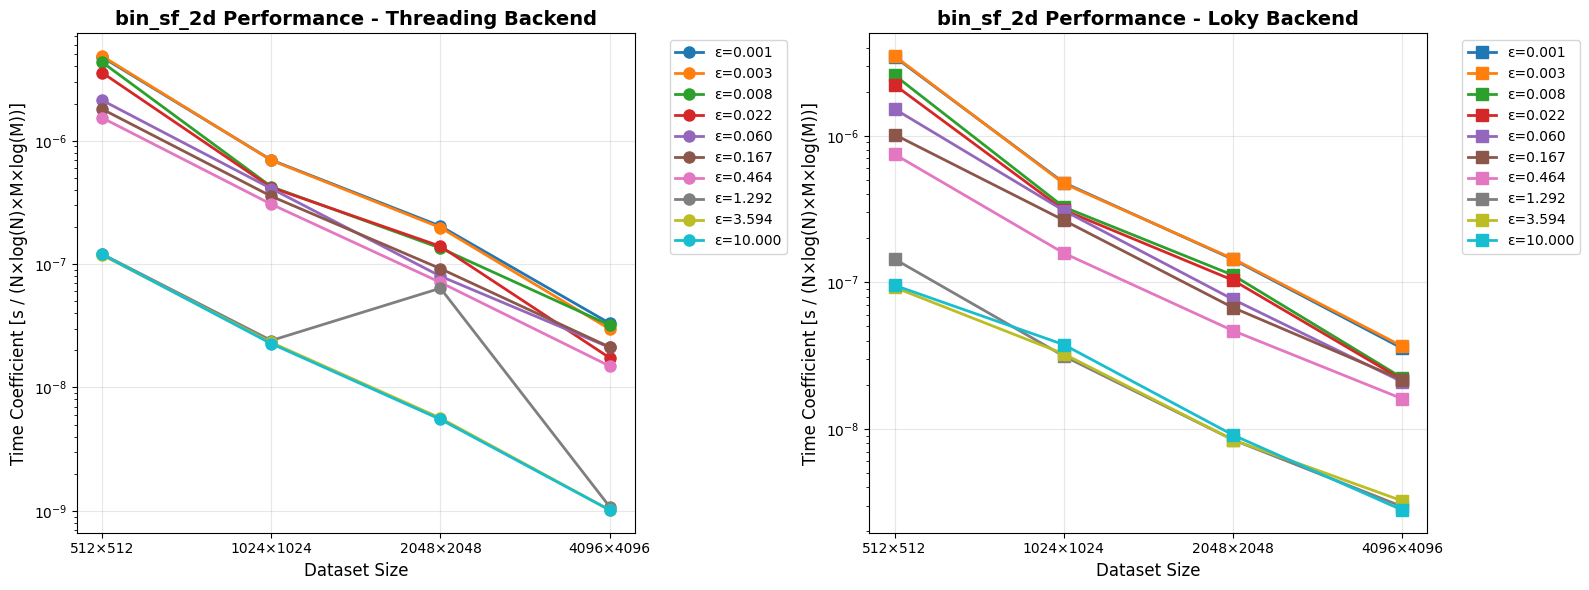

In [1]:
"""
Analysis 1: bin_sf_2d Performance Benchmark
Measures execution time for different dataset sizes and epsilon thresholds
Tests both threading and loky backends
"""

import numpy as np
import xarray as xr
import time
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd
import os
from pyturbo_sf import bin_sf_2d
import gc

def create_synthetic_dataset(size):
    """DYCOMS 2D dataset with specified size."""
    path_data = '/home/aayouche/Téléchargements/'
    idt = 10
    ds = xr.open_dataset(path_data+'dycoms.slice.9.40810.nc')

    u = ds.u
    v = ds.v
    b = ds.b


    x =  ds.x
    y = ds.y

    Y,X = np.meshgrid(y.values,x.values,indexing='ij')
    gc.collect()

    # Create the xarray dataset
    dso = xr.Dataset(    
        data_vars={
            'u': u,  # These are DataArrays - correct usage
            'v': v,
            'b': b
        }, 
        coords={
            'x': (['y', 'x'], X),
            'y': (['y', 'x'], Y)
    })

    
    return dso.isel(y=slice(0,size),x=slice(0,size))

def benchmark_bin_sf_2d():
    """Run the benchmark for bin_sf_2d function."""
    
    # Parameters
    dataset_sizes = [512, 1024, 2048, 4096]
    eps_thresholds = np.logspace(-3, 1.0, 10)  # 10 values from 0.001 to ~0.316
    bootsize = {'x': 16, 'y': 16}
    initial_nbootstrap = 60
    max_nbootstrap = 1060
    step_nbootstrap = 500
    backends = ['threading', 'loky']
    
    # Create bins for structure function
    n_bins = 11
    
    # Store results
    results = {
        'size': [],
        'epsilon': [],
        'backend': [],
        'execution_time': [],
        'time_coefficient': [],
        'converged_fraction': [],
        'total_bootstraps': []
    }
    
    print("Starting bin_sf_2d Performance Benchmark")
    print("=" * 80)
    
    for backend in backends:
        print(f"\nTesting backend: {backend}")
        print("-" * 40)
        
        for size in dataset_sizes:
            print(f"\nDataset size: {size}×{size}")
            
            # Create dataset
            ds = create_synthetic_dataset(size)
            
            # Create bins (logarithmic in this case)
            max_dist = size*1.25
            bins_r = np.logspace(np.log10(1.25), np.log10(max_dist), 14)
            bins = {
                'x': bins_r,
                'y': bins_r
            }
            
            for eps in eps_thresholds:
                print(f"  Testing epsilon = {eps:.4f}...", end='', flush=True)
                
                try:
                    # Time the execution
                    start_time = time.time()
                    
                    result_ds = bin_sf_2d(
                        ds=ds,
                        variables_names=['u', 'v'],
                        order=2,
                        bins=bins,
                        bootsize=bootsize,
                        fun='longitudinal',
                        initial_nbootstrap=initial_nbootstrap,
                        max_nbootstrap=max_nbootstrap,
                        step_nbootstrap=step_nbootstrap,
                        convergence_eps=eps,
                        n_jobs=-1,
                        backend=backend
                    )
                    
                    execution_time = time.time() - start_time
                    
                    # Calculate time coefficient
                    N = M = size
                    complexity = N * np.log(N) * M * np.log(M)
                    time_coefficient = execution_time / complexity
                    
                    # Calculate convergence statistics
                    converged = result_ds['converged'].values
                    valid_bins = result_ds['point_counts'].values > 10
                    converged_fraction = np.sum(converged & valid_bins) / np.sum(valid_bins) if np.sum(valid_bins) > 0 else 0
                    
                    total_bootstraps = np.sum(result_ds['nbootstraps'].values[valid_bins])
                    
                    # Store results
                    results['size'].append(f"{size}×{size}")
                    results['epsilon'].append(eps)
                    results['backend'].append(backend)
                    results['execution_time'].append(execution_time)
                    results['time_coefficient'].append(time_coefficient)
                    results['converged_fraction'].append(converged_fraction)
                    results['total_bootstraps'].append(total_bootstraps)
                    
                    print(f" Done! Time: {execution_time:.2f}s, Converged: {converged_fraction:.1%}")
                    
                except Exception as e:
                    print(f" ERROR: {str(e)}")
                    results['size'].append(f"{size}×{size}")
                    results['epsilon'].append(eps)
                    results['backend'].append(backend)
                    results['execution_time'].append(np.nan)
                    results['time_coefficient'].append(np.nan)
                    results['converged_fraction'].append(np.nan)
                    results['total_bootstraps'].append(np.nan)
                gc.collect()
    # Convert to DataFrame for easier manipulation
    df = pd.DataFrame(results)
    
    # Create plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Threading backend
    threading_df = df[df['backend'] == 'threading']
    for eps in eps_thresholds:
        eps_data = threading_df[threading_df['epsilon'] == eps]
        if not eps_data.empty:
            ax1.plot(eps_data['size'], eps_data['time_coefficient'], 
                    marker='o', label=f'ε={eps:.3f}', linewidth=2, markersize=8)
    
    ax1.set_xlabel('Dataset Size', fontsize=12)
    ax1.set_ylabel('Time Coefficient [s / (N×log(N)×M×log(M))]', fontsize=12)
    ax1.set_title('bin_sf_2d Performance - Threading Backend', fontsize=14, fontweight='bold')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')
    
    # Plot 2: Loky backend
    loky_df = df[df['backend'] == 'loky']
    for eps in eps_thresholds:
        eps_data = loky_df[loky_df['epsilon'] == eps]
        if not eps_data.empty:
            ax2.plot(eps_data['size'], eps_data['time_coefficient'], 
                    marker='s', label=f'ε={eps:.3f}', linewidth=2, markersize=8)
    
    ax2.set_xlabel('Dataset Size', fontsize=12)
    ax2.set_ylabel('Time Coefficient [s / (N×log(N)×M×log(M))]', fontsize=12)
    ax2.set_title('bin_sf_2d Performance - Loky Backend', fontsize=14, fontweight='bold')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_yscale('log')
    
    plt.tight_layout()
    
    # Save results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(f'bin_sf_2d_performance_{timestamp}.png', dpi=300, bbox_inches='tight')
    df.to_csv(f'bin_sf_2d_results_{timestamp}.csv', index=False)
    
    print("\n" + "=" * 80)
    print("Benchmark completed!")
    print(f"Results saved to: bin_sf_2d_results_{timestamp}.csv")
    print(f"Plot saved to: bin_sf_2d_performance_{timestamp}.png")
    
    # Print summary statistics
    print("\nSummary Statistics:")
    print("-" * 40)
    for backend in backends:
        backend_df = df[df['backend'] == backend]
        avg_time = backend_df['execution_time'].mean()
        avg_converged = backend_df['converged_fraction'].mean()
        print(f"{backend.capitalize()} backend:")
        print(f"  Average execution time: {avg_time:.2f}s")
        print(f"  Average convergence rate: {avg_converged:.1%}")
    
    return df

if __name__ == "__main__":
    # Note: Make sure to import bin_sf_2d from your module before running
    # Uncomment the import at the top and adjust the path as needed
    
    results_df = benchmark_bin_sf_2d()

# Plot Benchmark Results

/tmp/ipykernel_7172/2840690795.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Plot saved to: bin_sf_2d_performance_ratio_20250731_104608.png

Detailed Performance Comparison:
Size 512×512, ε=0.008: Loky is 67% faster
Size 512×512, ε=0.022: Loky is 60% faster
Size 512×512, ε=0.167: Loky is 77% faster
Size 512×512, ε=0.464: Loky is 105% faster
Size 1024×1024, ε=0.464: Loky is 93% faster
Size 2048×2048, ε=0.464: Loky is 52% faster
Size 2048×2048, ε=1.292: Loky is 656% faster
Size 4096×4096, ε=1.292: Threading is 173% faster

Overall average ratio: 1.471
→ Loky is 47% faster on average

Ratio range: 0.366 to 7.557
Cases where Loky is faster: 24 / 32
Cases where Threading is faster: 8 / 32


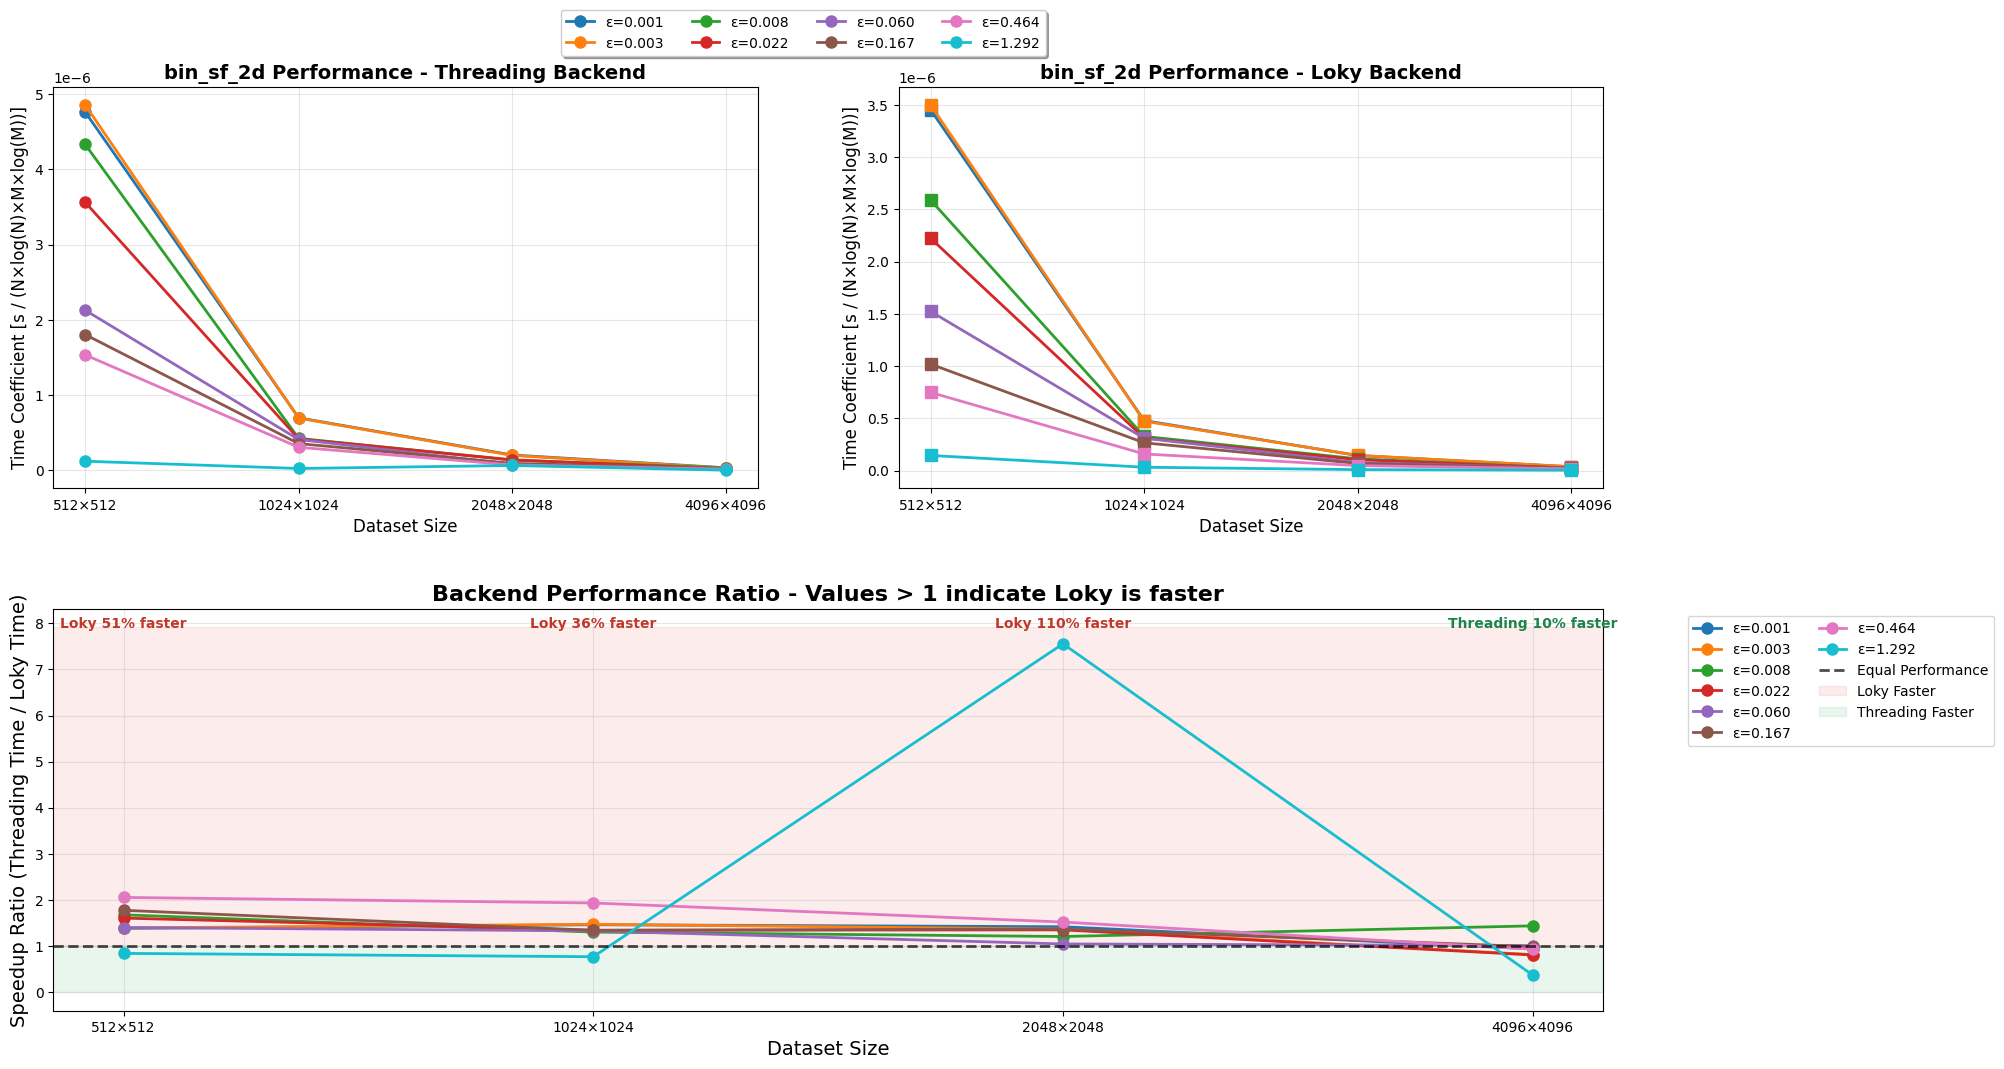

In [11]:
"""
Enhanced performance comparison with speedup ratio plot
Shows how much faster loky is compared to threading
Uses colorblind-friendly color palettes
"""

import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd

def plot_performance_with_ratio(results_df, save_plots=True, use_matplotlib_colors=False):
    """
    Create performance plots with speedup ratio comparison.
    
    Parameters
    ----------
    results_df : pd.DataFrame
        DataFrame with performance results
    save_plots : bool
        Whether to save the plots to file
    use_matplotlib_colors : bool
        If True, use matplotlib's 'tab10' colormap instead of custom colors
    """
    
    eps_thresholds = np.logspace(-3, 1.0, 10)[:-2]
    df = results_df
    
    # Define colorblind-friendly colors
    if use_matplotlib_colors:
        # Use matplotlib's colorblind-friendly 'tab10' colormap
        from matplotlib import cm
        cb_colors = list(cm.get_cmap('tab10').colors[:len(eps_thresholds)])
    else:
        # Using a combination of ColorBrewer qualitative schemes
        # These colors are distinguishable for most types of color vision deficiency
        cb_colors = [
            '#1f77b4',  # blue
            '#ff7f0e',  # orange
            '#2ca02c',  # green
            '#d62728',  # red
            '#9467bd',  # purple
            '#8c564b',  # brown
            '#e377c2',  # pink
            '#17becf',  # cyan
        ]
    
    # Create figure with 3 subplots
    fig = plt.figure(figsize=(20, 12))
    
    # Create grid with 2 rows
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.3)
    
    # Top row: individual backend performances
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    # Bottom row: speedup ratio (spanning both columns)
    ax3 = fig.add_subplot(gs[1, :])
    
    # Plot 1: Threading backend
    threading_df = df[df['backend'] == 'threading']
    lines1 = []
    for i, eps in enumerate(eps_thresholds):
        eps_data = threading_df[threading_df['epsilon'] == eps]
        if not eps_data.empty:
            line, = ax1.plot(eps_data['size'], eps_data['time_coefficient'], 
                    marker='o', label=f'ε={eps:.3f}', linewidth=2, markersize=8,
                    color=cb_colors[i % len(cb_colors)])
            lines1.append(line)
    
    ax1.set_xlabel('Dataset Size', fontsize=12)
    ax1.set_ylabel('Time Coefficient [s / (N×log(N)×M×log(M))]', fontsize=12)
    ax1.set_title('bin_sf_2d Performance - Threading Backend', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Loky backend
    loky_df = df[df['backend'] == 'loky']
    for i, eps in enumerate(eps_thresholds):
        eps_data = loky_df[loky_df['epsilon'] == eps]
        if not eps_data.empty:
            ax2.plot(eps_data['size'], eps_data['time_coefficient'], 
                    marker='s', label=f'ε={eps:.3f}', linewidth=2, markersize=8,
                    color=cb_colors[i % len(cb_colors)])
    
    ax2.set_xlabel('Dataset Size', fontsize=12)
    ax2.set_ylabel('Time Coefficient [s / (N×log(N)×M×log(M))]', fontsize=12)
    ax2.set_title('bin_sf_2d Performance - Loky Backend', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Create a single legend for both top plots
    # Get the lines and labels from the first subplot (they're the same for both)
    labels = [line.get_label() for line in lines1]
    # Create legend above both plots
    fig.legend(lines1, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), 
               ncol=4, fontsize=10, frameon=True, fancybox=True, shadow=True)
    
    # Plot 3: Speedup Ratio (Threading/Loky)
    # Calculate ratios for each epsilon and dataset size
    sizes = df['size'].unique()
    
    for i, eps in enumerate(eps_thresholds):
        ratios = []
        valid_sizes = []
        
        for size in sizes:
            # Get threading time coefficient
            threading_time = threading_df[(threading_df['epsilon'] == eps) & 
                                        (threading_df['size'] == size)]['time_coefficient'].values
            # Get loky time coefficient
            loky_time = loky_df[(loky_df['epsilon'] == eps) & 
                              (loky_df['size'] == size)]['time_coefficient'].values
            
            if len(threading_time) > 0 and len(loky_time) > 0 and loky_time[0] > 0:
                ratio = threading_time[0] / loky_time[0]
                ratios.append(ratio)
                valid_sizes.append(size)
        
        if ratios:
            ax3.plot(valid_sizes, ratios, marker='o', label=f'ε={eps:.3f}', 
                    linewidth=2, markersize=8, color=cb_colors[i % len(cb_colors)])
    
    # Add reference line at ratio = 1
    ax3.axhline(y=1, color='black', linestyle='--', linewidth=2, alpha=0.7, 
                label='Equal Performance')
    
    # Add shaded regions with colorblind-friendly colors
    ax3.axhspan(1, ax3.get_ylim()[1], alpha=0.1, color='#e74c3c', 
                label='Loky Faster')
    ax3.axhspan(ax3.get_ylim()[0], 1, alpha=0.1, color='#27ae60', 
                label='Threading Faster')
    
    ax3.set_xlabel('Dataset Size', fontsize=14)
    ax3.set_ylabel('Speedup Ratio (Threading Time / Loky Time)', fontsize=14)
    ax3.set_title('Backend Performance Ratio - Values > 1 indicate Loky is faster', 
                  fontsize=16, fontweight='bold')
    ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, ncol=2)
    ax3.grid(True, alpha=0.3)
    
    # Add percentage annotations
    y_pos = ax3.get_ylim()[1] * 0.95
    for i, size in enumerate(valid_sizes):
        # Calculate average ratio across all epsilons for this size
        size_ratios = []
        for eps in eps_thresholds:
            threading_time = threading_df[(threading_df['epsilon'] == eps) & 
                                        (threading_df['size'] == size)]['time_coefficient'].values
            loky_time = loky_df[(loky_df['epsilon'] == eps) & 
                              (loky_df['size'] == size)]['time_coefficient'].values
            if len(threading_time) > 0 and len(loky_time) > 0 and loky_time[0] > 0:
                size_ratios.append(threading_time[0] / loky_time[0])
        
        if size_ratios:
            avg_ratio = np.mean(size_ratios)
            if avg_ratio > 1:
                speedup_pct = (avg_ratio - 1) * 100
                ax3.text(i, y_pos, f'Loky {speedup_pct:.0f}% faster', 
                        ha='center', fontsize=10, color='#c0392b', fontweight='bold')
            else:
                speedup_pct = (1/avg_ratio - 1) * 100
                ax3.text(i, y_pos, f'Threading {speedup_pct:.0f}% faster', 
                        ha='center', fontsize=10, color='#1e8449', fontweight='bold')
    
    plt.tight_layout()
    
    if save_plots:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        plt.savefig(f'bin_sf_2d_performance_ratio_{timestamp}.png', dpi=300, bbox_inches='tight')
        print(f"Plot saved to: bin_sf_2d_performance_ratio_{timestamp}.png")
    
    # Print detailed statistics
    print("\nDetailed Performance Comparison:")
    print("="*80)
    
    # Calculate overall statistics
    all_ratios = []
    sizes = df['size'].unique()
    
    for eps in eps_thresholds:
        for size in sizes:
            threading_time = threading_df[(threading_df['epsilon'] == eps) & 
                                        (threading_df['size'] == size)]['time_coefficient'].values
            loky_time = loky_df[(loky_df['epsilon'] == eps) & 
                              (loky_df['size'] == size)]['time_coefficient'].values
            
            if len(threading_time) > 0 and len(loky_time) > 0 and loky_time[0] > 0:
                ratio = threading_time[0] / loky_time[0]
                all_ratios.append(ratio)
                
                # Print individual comparisons for extreme cases
                if ratio > 1.5 or ratio < 0.67:
                    if ratio > 1:
                        faster = "Loky"
                        speedup = (ratio - 1) * 100
                    else:
                        faster = "Threading"
                        speedup = (1/ratio - 1) * 100
                    print(f"Size {size}, ε={eps:.3f}: {faster} is {speedup:.0f}% faster")
    
    if all_ratios:
        avg_ratio = np.mean(all_ratios)
        print(f"\nOverall average ratio: {avg_ratio:.3f}")
        if avg_ratio > 1:
            print(f"→ Loky is {(avg_ratio-1)*100:.0f}% faster on average")
        else:
            print(f"→ Threading is {(1/avg_ratio-1)*100:.0f}% faster on average")
        
        print(f"\nRatio range: {np.min(all_ratios):.3f} to {np.max(all_ratios):.3f}")
        print(f"Cases where Loky is faster: {np.sum(np.array(all_ratios) > 1)} / {len(all_ratios)}")
        print(f"Cases where Threading is faster: {np.sum(np.array(all_ratios) < 1)} / {len(all_ratios)}")
    
    return fig


# Usage example:
if __name__ == "__main__":
    fig = plot_performance_with_ratio(results_df, save_plots=True)
    
